# Chinese COVID-19 Weibo Sentiment Analysis

### Machine Learning Mini-Project

**Objective:**  
To develop a machine learning system that classifies Chinese Weibo posts into positive and negative sentiment categories.

This project compares three supervised machine learning algorithms — Naive Bayes, Logistic Regression, and Support Vector Machine (SVM) — using TF-IDF features and Chinese text preprocessing with Jieba.

## 1. Problem Statement

The objective of this project is to build a sentiment classification model for Chinese Weibo posts related to COVID-19. The system classifies posts into two sentiment categories:

- **Positive**
- **Negative**

Multiple machine learning models are trained and evaluated to determine which approach performs best for this task.

In [3]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/COVID-19-Weibo-data/COVID-19-sentiment-analysis-dataset-Weibo/master/labeledData.csv"

covid_df = pd.read_csv(url)

print("Dataset shape:", covid_df.shape)
print("\nColumns:")
print(covid_df.columns.tolist())

print("\nFirst 5 rows:")
display(covid_df.head())

Dataset shape: (21173, 2)

Columns:
['review', 'label']

First 5 rows:


,review,label
0,不过，喜欢4.0原生态的界面！,2
1,又要重复我每年必说的台词了，2010就要过去了，我很怀念它。,2
2,至少，它看上去很美。,2
3,这家位于槟城George Town，Tunes Hotel斜对面的饼家，家庭式作业，她的咸蛋...,2
4,很野味哦。。。,2


In [10]:
print(covid_df.columns)

for column in covid_df.columns:
    print("\nCOLUMN:", column)
    print(covid_df[column].head())

Index(['review', 'label'], dtype='object')

COLUMN: review
0                                      不过，喜欢4.0原生态的界面！
1                       又要重复我每年必说的台词了，2010就要过去了，我很怀念它。
2                                           至少，它看上去很美。
3    这家位于槟城George Town，Tunes Hotel斜对面的饼家，家庭式作业，她的咸蛋...
4                                              很野味哦。。。
Name: review, dtype: object

COLUMN: label
0    2
1    2
2    2
3    2
4    2
Name: label, dtype: int64


In [34]:
label_map = {
    0: "Negative",   # Fear
    1: "Negative",   # Disgust
    2: "Positive",   # Optimism
    3: "Neutral",    # Surprise
    4: "Positive",   # Gratitude
    5: "Negative",   # Sadness
    6: "Negative"    # Anger
}

covid_df["sentiment"] = covid_df["label"].map(label_map)

print("Sentiment distribution:")
print(covid_df["sentiment"].value_counts())

Sentiment distribution:
sentiment
Negative    11361
Positive     6667
Neutral      3145
Name: count, dtype: int64


## 4. Dataset Filtering

Only posts labelled as **Positive** or **Negative** are retained for the binary sentiment classification task.


In [35]:
sentiment_df = covid_df[
    covid_df["sentiment"].isin(["Positive", "Negative"])
].copy()

print("Final dataset size:", len(sentiment_df))

print("\nFinal sentiment distribution:")
print(sentiment_df["sentiment"].value_counts())

print("\nSample:")
display(sentiment_df[["review", "sentiment"]].sample(10, random_state=42))

Final dataset size: 18028

Final sentiment distribution:
sentiment
Negative    11361
Positive     6667
Name: count, dtype: int64

Sample:


,review,sentiment
4505,感谢祖国,Positive
7405,是啊，我也不知道啊！,Negative
5688,第一次吃，是老妈做的，我，想家了[泪],Negative
5929,阿弥陀佛。,Negative
18314,要么瘦，要么死！,Negative
9337,是啊，所以说的是老百姓愿意的行为。,Negative
8748,这就是法治问题的意义。管不？,Negative
18252,惹大点敢不敢…,Negative
8650,你们两个人还真是不对不对你这么说的嘛~~~,Negative
7096,还不尼玛打他等什么。。。,Negative


In [37]:
import re
import jieba

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\S+", "", text)

    # Remove hashtags
    text = re.sub(r"#.*?#", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def tokenize_text(text):
    return " ".join(jieba.cut(text))


sentiment_df["clean_text"] = sentiment_df["review"].apply(clean_text)

sentiment_df["processed_text"] = sentiment_df["clean_text"].apply(
    tokenize_text
)

display(
    sentiment_df[
        ["review", "clean_text", "processed_text", "sentiment"]
    ].head(10)
)

,review,clean_text,processed_text,sentiment
0,不过，喜欢4.0原生态的界面！,不过，喜欢4.0原生态的界面！,不过 ， 喜欢 4.0 原生态 的 界面 ！,Positive
1,又要重复我每年必说的台词了，2010就要过去了，我很怀念它。,又要重复我每年必说的台词了，2010就要过去了，我很怀念它。,又 要 重复 我 每年 必说 的 台词 了 ， 2010 就要 过去 了 ， 我 很 怀念 它 。,Positive
2,至少，它看上去很美。,至少，它看上去很美。,至少 ， 它 看上去 很 美 。,Positive
3,这家位于槟城George Town，Tunes Hotel斜对面的饼家，家庭式作业，她的咸蛋...,这家位于槟城George Town，Tunes Hotel斜对面的饼家，家庭式作业，她的咸蛋...,这家 位于 槟城 George Town ， Tunes Hotel 斜对面 的 饼...,Positive
4,很野味哦。。。,很野味哦。。。,很 野味 哦 。 。 。,Positive
5,白胡椒祛湿。。。,白胡椒祛湿。。。,白胡椒 祛湿 。 。 。,Positive
6,黑胡椒很香。。,黑胡椒很香。。,黑胡椒 很香 。 。,Positive
7,我爱你们两个老家伙～,我爱你们两个老家伙～,我 爱 你们 两个 老家伙 ～,Positive
8,不过这届比赛从首轮就不乏焦点战，沃兹对杜尔科，萨芬娜对小克，休伊特对纳班，场场看点十足啊！,不过这届比赛从首轮就不乏焦点战，沃兹对杜尔科，萨芬娜对小克，休伊特对纳班，场场看点十足啊！,不过 这届 比赛 从 首轮 就 不乏 焦点 战 ， 沃兹 对 杜尔科 ， 萨芬娜 对小克 ，...,Positive
9,好想看呐混蛋,好想看呐混蛋,好 想 看 呐 混蛋,Positive


### Removing Duplicate and Empty Posts

After preprocessing, duplicate posts are removed to reduce repeated information in the dataset.

In [38]:
sentiment_df = sentiment_df.drop_duplicates(
    subset=["processed_text"]
)

sentiment_df = sentiment_df[
    sentiment_df["processed_text"].str.strip() != ""
]

print("Dataset after cleaning:", len(sentiment_df))

print("\nSentiment distribution:")
print(sentiment_df["sentiment"].value_counts())

Dataset after cleaning: 9745

Sentiment distribution:
sentiment
Negative    6275
Positive    3470
Name: count, dtype: int64


In [39]:
from sklearn.model_selection import train_test_split

X = sentiment_df["processed_text"]
y = sentiment_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7796
Testing samples: 1949


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix:", X_test_tfidf.shape)

Training feature matrix: (7796, 5000)
Testing feature matrix: (1949, 5000)


In [40]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 1. Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

# 2. Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

# 3. Support Vector Machine
svm_model = LinearSVC(
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

# Compare models
results = []
results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        nb_pred
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        svm_pred
    )
)
results_df = pd.DataFrame(results)
print("MODEL PERFORMANCE")
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8476,0.8523,0.8476,0.8414
1,Logistic Regression,0.8430,0.8526,0.8430,0.8346
2,SVM,0.8481,0.8468,0.8481,0.8456


In [41]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("BEST MODEL")
print("-------------------------")
print("Model     :", best_model["Model"])
print("Accuracy  :", round(best_model["Accuracy"], 4))
print("Precision :", round(best_model["Precision"], 4))
print("Recall    :", round(best_model["Recall"], 4))
print("F1 Score  :", round(best_model["F1 Score"], 4))

BEST MODEL
-------------------------
Model     : SVM
Accuracy  : 0.8481
Precision : 0.8468
Recall    : 0.8481
F1 Score  : 0.8456


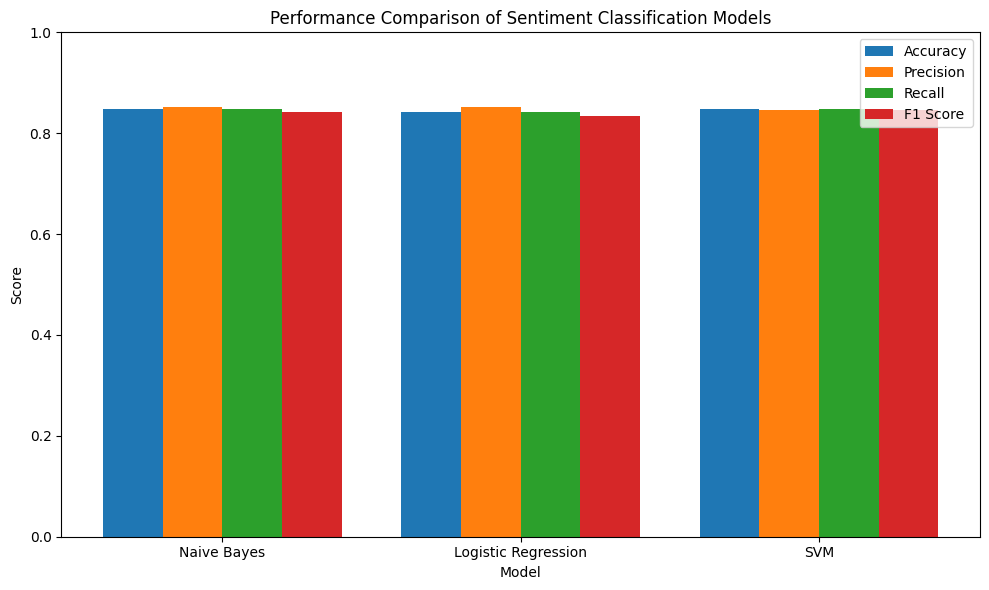

In [20]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(results_df["Model"]))
width = 0.2

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(x, results_df["Model"])
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Performance Comparison of Sentiment Classification Models")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

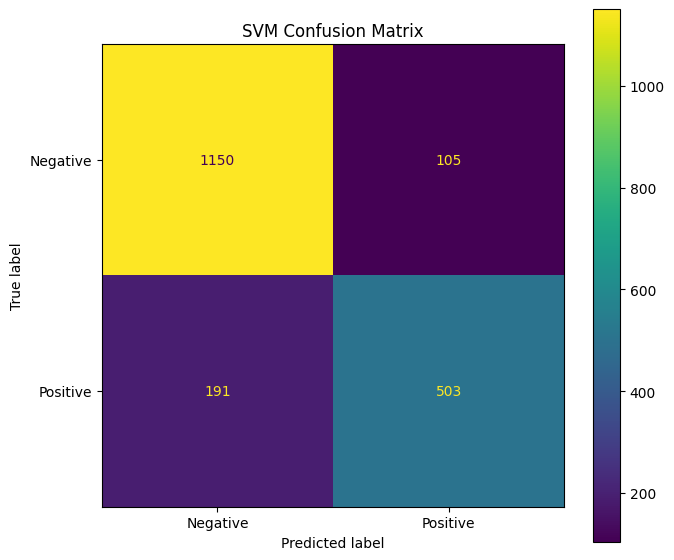

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=["Negative", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

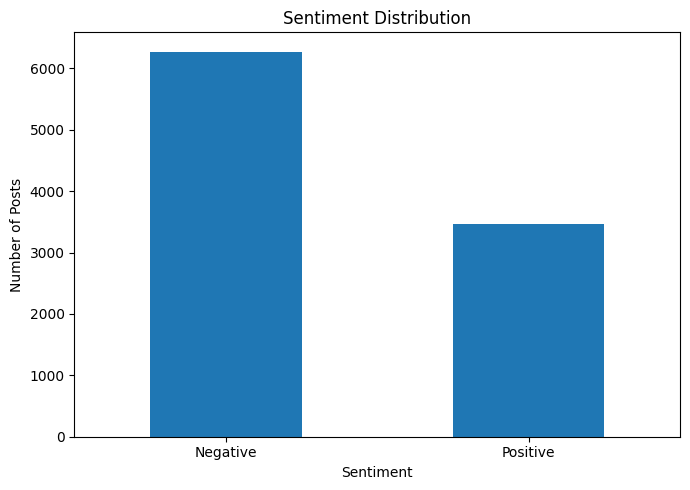

sentiment
Negative    6275
Positive    3470
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(7, 5))

sentiment_counts = sentiment_df["sentiment"].value_counts()

sentiment_counts.plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(sentiment_counts)

In [23]:
def predict_sentiment(text):

    cleaned = clean_text(text)
    processed = tokenize_text(cleaned)

    vectorized = vectorizer.transform([processed])

    prediction = svm_model.predict(vectorized)[0]

    return prediction

In [24]:
test_sentences = [
    "我觉得疫苗非常安全，大家应该积极接种。",
    "这个疫苗让我非常担心，我不想接种。",
    "疫情终于快结束了，希望大家都能健康。"
]

for sentence in test_sentences:
    prediction = predict_sentiment(sentence)

    print("Text:", sentence)
    print("Prediction:", prediction)
    print("-" * 60)

Text: 我觉得疫苗非常安全，大家应该积极接种。
Prediction: Positive
------------------------------------------------------------
Text: 这个疫苗让我非常担心，我不想接种。
Prediction: Negative
------------------------------------------------------------
Text: 疫情终于快结束了，希望大家都能健康。
Prediction: Positive
------------------------------------------------------------


In [25]:
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
        Naive Bayes  0.847614   0.852335 0.847614  0.841405
Logistic Regression  0.842996   0.852552 0.842996  0.834643
                SVM  0.848127   0.846792 0.848127  0.845627
